Dataset loaded successfully from local directory.
Data Cleaning Complete. Clean Dataset Shape: (7043, 20)

--- Feature Engineering Summary ---
   AverageMonthlySpending  ServiceCount CustomerSpendingCategory
0               29.850000             1                      Low
1               55.573529             3                   Medium
2               54.075000             3                   Medium
3               40.905556             3                      Low
4               75.825000             1                   Medium

Shape after One-Hot Encoding: (7043, 35)
Training samples: 5634 | Testing samples: 1409

TASK 8: MODEL PERFORMANCE METRICS EVALUATION
                          Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression         0.7410     0.5077  0.7888    0.6178   0.8416
Random Forest Classifier    0.7736     0.5626  0.6604    0.6076   0.8353


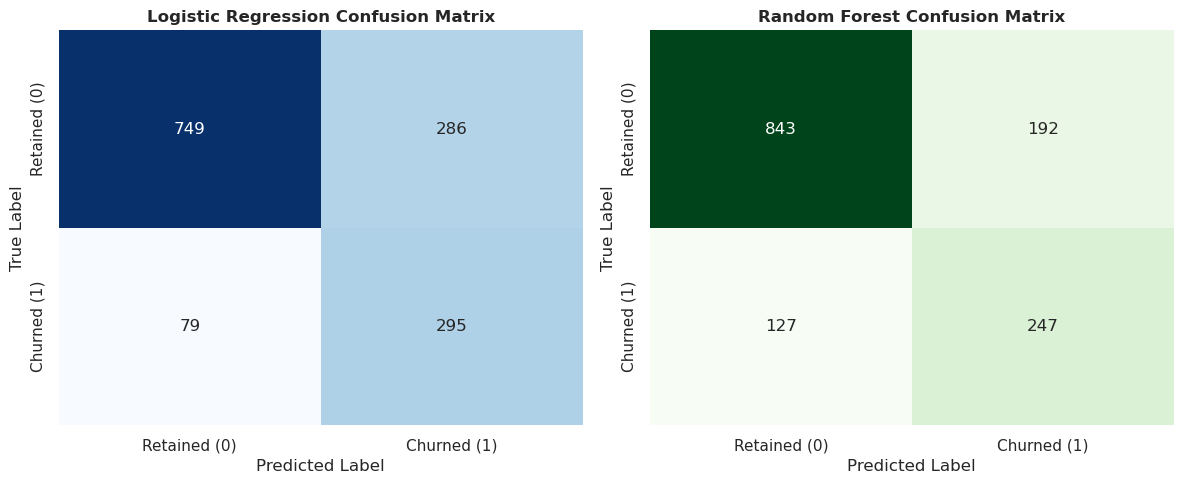

In [1]:
"""
Telco Customer Churn Prediction — Feature Engineering & Model Comparison
Author: Machine Learning Engineer
Dataset: Telco Customer Churn
Models: Logistic Regression vs. Random Forest Classifier
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Set plotting defaults
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# ==============================================================================
# TASK 1 & 2: DATA LOADING & PREPROCESSING
# ==============================================================================
file_path = r'C:\Users\bhatt\Downloads\archive (5)\WA_Fn-UseC_-Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully from local directory.")
except FileNotFoundError:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Loaded dataset from working directory.")

# Drop identifier column
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert TotalCharges to numeric float (coercing whitespace ' ' to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing TotalCharges (which occur when tenure == 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Map target variable Churn to binary (1: Churn, 0: No Churn)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Data Cleaning Complete. Clean Dataset Shape: {df.shape}")

# ==============================================================================
# TASK 3: FEATURE ENGINEERING
# ==============================================================================
df_fe = df.copy()

# Feature 1: Average Monthly Spending (avoid zero-division with np.maximum)
df_fe['AverageMonthlySpending'] = df_fe['TotalCharges'] / np.maximum(df_fe['tenure'], 1)

# Feature 2: ServiceCount (Total number of subscribed add-on services)
service_columns = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# A service is active if value is 'Yes'
df_fe['ServiceCount'] = (df_fe[service_columns] == 'Yes').sum(axis=1)

# Feature 3: CustomerSpendingCategory (Quantile-based spending tier)
df_fe['CustomerSpendingCategory'] = pd.qcut(
    df_fe['MonthlyCharges'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print("\n--- Feature Engineering Summary ---")
print(df_fe[['AverageMonthlySpending', 'ServiceCount', 'CustomerSpendingCategory']].head())

# ==============================================================================
# TASK 4: CATEGORICAL ENCODING
# ==============================================================================
# Identify categorical columns (excluding target)
categorical_cols = df_fe.select_dtypes(include=['object', 'category']).columns.tolist()

# Perform One-Hot Encoding with drop_first=True to avoid dummy variable trap
df_encoded = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)

print(f"\nShape after One-Hot Encoding: {df_encoded.shape}")

# ==============================================================================
# TASK 5 & 6: DATASET SPLITTING & FEATURE SCALING
# ==============================================================================
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Stratified 80/20 Train-Test Split to preserve target class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Identify numerical features requiring standardization
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpending', 'ServiceCount']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler on training set only to prevent data leakage
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

# ==============================================================================
# TASK 7: MODEL TRAINING
# ==============================================================================
# 1. Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# 2. Random Forest Classifier Model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)  # Tree models do not strictly require scaled features

# Predictions & Probability Estimates
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ==============================================================================
# TASK 8: EVALUATION & PERFORMANCE METRICS
# ==============================================================================
def evaluate_performance(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}

metrics_lr = evaluate_performance(y_test, y_pred_lr, y_prob_lr)
metrics_rf = evaluate_performance(y_test, y_pred_rf, y_prob_rf)

# Summary DataFrame
results_df = pd.DataFrame([metrics_lr, metrics_rf], index=['Logistic Regression', 'Random Forest Classifier'])

print("\n" + "="*65)
print("TASK 8: MODEL PERFORMANCE METRICS EVALUATION")
print("="*65)
print(results_df.round(4))

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[0].set_yticklabels(['Retained (0)', 'Churned (1)'])

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[1].set_yticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()